# Exercise 3: Hazard classification from exceedance probabilities — Comoros

Four rasters, each giving the probability that flooding reaches a particular depth.
This notebook combines them into a single hazard classification and then works out
which buildings and roads fall inside each level.

The question being answered is different from Exercise 2:

> **What are the odds of at least 30 cm of water here?**

Exercise 2 sampled *depth* from one specific storm. This works from
**exceedance probabilities** across an ensemble, which is a more useful product for
a forecast.

**The case.** One forecast cycle of the UFFIS chain for the Comoros,
**27 April 2024, 00:00 UTC**. Rainfall enters as 50 members — five StormLab
realizations run from each of ten satellite-rainfall analysis states. No hydraulic
model runs when a storm approaches: each of the 55 ADM3 communes has a library of
200 precomputed scenarios, each member's rainfall total selects the closest library
scenario, and the probability of exceeding a depth at a cell is the share of the 50
members whose matched scenario floods that cell that deeply.

**What is particular to the Comoros, and shapes everything below**

- **Pluvial only.** The three island models were run with rainfall forcing and no
  upstream boundary discharge, so there is no fluvial index and every site config
  disables it. A hazard level here means rain, never a river rising.
- **Per commune, not per country.** Products are written one set per commune, so a
  unit has to be chosen before any path resolves. This notebook uses **Moroni**
  (KM274), the capital, on Grande Comore.
- **EPSG:5629** (Moznet / UTM zone 38S) at 30.57 m — the island model's own grid,
  not a reprojected copy. Guatemala and Haiti ship EPSG:3857 copies; nothing is
  copied here.
- **The receptor file is per island**, so it holds all 29 communes of Grande
  Comore and its probabilities are stored as **percent**, not as fractions.
  Section 3 deals with both.

**What to take away from it**

- how four nested probability layers collapse into one classification, and why the
  rule assigns levels in ascending order
- why a threshold is a modelling decision rather than a detail
- why the units a column is stored in are part of its contract, and what a silent
  factor of 100 does to an impact table
- why the extent of the raster and the extent of the feature table have to be
  reconciled before either is reported

**Workflow**

1. Classify pixels into hazard levels with the escalating-gate rule
2. Classify the buildings and roads directly, on the same gates
3. Build the impact table
4. Draw both together

Everything is read from a public S3 bucket. Nothing is stored locally except one
cached download.

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from matplotlib.colors import BoundaryNorm, ListedColormap

%matplotlib inline

BUCKET = "https://cog-s3-test-401506828094-us-east-1-an.s3.us-east-1.amazonaws.com"
ROOT = (
    f"{BUCKET}/Comoros_training/Comoros_cycle_20240427_0000UTC"
    "/Comoros_cycle_20240427_0000UTC"
)
CYCLE = "20240427.000000"

# Products are written one set per ADM3 commune, so a unit has to be named before
# any path resolves. Moroni is the capital; naming it also fixes the island,
# because receptors are filed one file per island rather than per commune.
UNIT = "KM274_Moroni"
PCODE = UNIT.split("_")[0]
ISLAND = "grande"

# The overbank variants. The driest scenario of each site config is its overbank
# reference, and subtracting it leaves flood signal rather than the commune's
# permanent standing water. The `pluvial/` directory alongside holds the same four
# rasters without that subtraction.
_FIM = f"{ROOT}/fim/{UNIT}/stream_sat_stormlab/pluvial_overbank"
PROB = {
    depth: f"{_FIM}/prob_depth_ge_{depth}_overbank.{CYCLE}.tif"
    for depth in ("10cm", "30cm", "70cm", "100cm")
}

# Buildings, roads, facilities and commune polygons for one island.
FEATURES = f"{ROOT}/ibf/receptors_{ISLAND}_{CYCLE}.gpkg"

print(f"cycle {CYCLE}, unit {UNIT}")

cycle 20240427.000000, unit KM274_Moroni


## 1. The four probability rasters

Each raster holds **P(flood depth ≥ threshold)** for one depth. A cell value of 0.3
in the 30 cm raster means *"in 30% of the 50 members, the water here reached at
least 30 cm"*.

All four are windowed on the commune plus a small buffer, so they are small — a few
hundred cells on a side rather than a national grid.

In [2]:
layers, meta = {}, {}
for name, url in PROB.items():
    with rasterio.open(url) as ds:
        layers[name] = ds.read(1, masked=True)
        meta[name] = {"crs": ds.crs, "shape": ds.shape,
                      "transform": ds.transform, "res": ds.res[0]}

for name, m in meta.items():
    arr = layers[name]
    print(f"prob_{name:<5} {m['crs']}  {m['shape'][0]} x {m['shape'][1]}  "
          f"{m['res']:.2f} m   max {arr.max():.2f}  "
          f"{len(np.unique(arr.compressed()))} distinct values")

print(f"\nall four share one grid: {len({v.shape for v in layers.values()}) == 1}")

prob_10cm  EPSG:5629  198 x 169  30.57 m   max 1.00  41 distinct values
prob_30cm  EPSG:5629  198 x 169  30.57 m   max 1.00  34 distinct values
prob_70cm  EPSG:5629  198 x 169  30.57 m   max 1.00  21 distinct values
prob_100cm EPSG:5629  198 x 169  30.57 m   max 1.00  10 distinct values

all four share one grid: True


## 2. The classification rule

Each hazard level is tied to **one** depth layer, and each has its own probability
threshold:

| level | driven by | notebook default threshold |
|---|---|---|
| Low | P(≥ 10 cm) | 0.8 |
| Medium | P(≥ 30 cm) | 0.8 |
| High | P(≥ 70 cm) | 0.8 |
| Severe | P(≥ 100 cm) | 0.8 |

A pixel takes the level of the **deepest** threshold it clears. That falls out of
assigning the levels in ascending order and letting later assignments win.

> **All four gates can sit at 0.8 here.** Every Comoros layer reaches 1.0 somewhere
> in the commune, including the 100 cm one, so the Severe class is reachable at any
> threshold. That is not true everywhere: Guatemala's 76 cm raster only ever holds
> 0 or 0.2, so its Severe gate has to be dropped to 0.2 or the class can never
> appear. Check what range a layer can actually reach before you expose a control
> for it.

cells per level: {'Normal': 32601, 'Low': 779, 'Medium': 74, 'High': 6, 'Severe': 2}


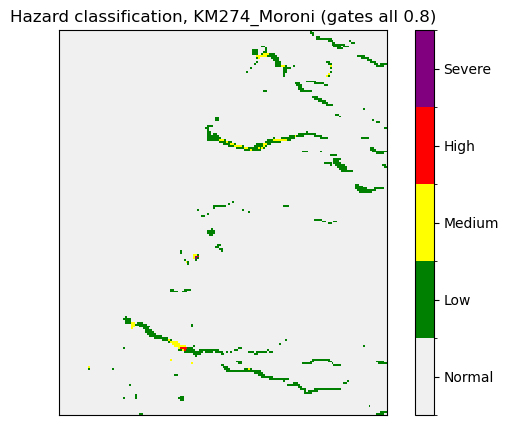

In [3]:
LEVELS = [(1, "green"), (2, "yellow"), (3, "red"), (4, "purple")]
LEVEL_LABEL = {0: "Normal", 1: "Low", 2: "Medium", 3: "High", 4: "Severe"}
NODATA = 255
ORDER = ["10cm", "30cm", "70cm", "100cm"]      # shallowest to deepest

LOW_THRESHOLD = 0.8
MEDIUM_THRESHOLD = 0.8
HIGH_THRESHOLD = 0.8
SEVERE_THRESHOLD = 0.8


def classify_hazard(layers, gates):
    """0 = Normal, 1..4 = hazard level, 255 = NoData."""
    # A pixel missing from any layer cannot be classified at all.
    invalid = np.zeros(layers[ORDER[0]].shape, dtype=bool)
    for name in ORDER:
        invalid |= np.ma.getmaskarray(layers[name])

    hazard = np.zeros(layers[ORDER[0]].shape, dtype=np.uint8)
    # Ascending order: each assignment overwrites the last, so the deepest
    # threshold a pixel clears is the one that sticks.
    for name, (value, _colour) in zip(ORDER, LEVELS):
        hazard[layers[name].filled(-np.inf) >= gates[value]] = value

    hazard[invalid] = NODATA
    return hazard


GATES = {1: LOW_THRESHOLD, 2: MEDIUM_THRESHOLD, 3: HIGH_THRESHOLD, 4: SEVERE_THRESHOLD}
hazard = classify_hazard(layers, GATES)

counts = {LEVEL_LABEL.get(int(v), "NoData"): int(n)
          for v, n in zip(*np.unique(hazard, return_counts=True))}
print("cells per level:", counts)

cmap = ListedColormap(["#f0f0f0", "green", "yellow", "red", "purple"])
norm = BoundaryNorm([0, 1, 2, 3, 4, 5], cmap.N)

fig, ax = plt.subplots(figsize=(7, 5))
drawn = np.where(hazard == NODATA, np.nan, hazard)
im = ax.imshow(drawn, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title(f"Hazard classification, {UNIT} (gates all {LOW_THRESHOLD})")
ax.set_xticks([]); ax.set_yticks([])
cbar = fig.colorbar(im, ax=ax, ticks=[0.5, 1.5, 2.5, 3.5, 4.5])
cbar.ax.set_yticklabels([LEVEL_LABEL[v] for v in [0, 1, 2, 3, 4]])
plt.show()

## 3. Classifying the buildings and roads

Every building and road in the receptor geopackage **already carries the four
probabilities**, sampled as the maximum over its own footprint, so the same gates
classify a feature directly — no rasterising involved.

Two things have to be fixed on the way in, and both are silent if missed:

- **The columns are percent, 0–100**, while every gate here is a fraction. A gate of
  0.8 is cleared by anything above 0.8 *percent*, which pulls roughly eight times
  too many features into a hazard level.
- **The file covers the whole island**, all 29 communes of Grande Comore, while the
  rasters above are Moroni alone. Both halves have to describe the same place or
  the table and the map are answering different questions.

In [4]:
import os
import tempfile
import urllib.request
from pathlib import Path

import pyogrio

# The geopackage's own layer names, and the `type` value each becomes.
LAYERS = {"building": "buildings", "road": "roads"}
# It names the exceedance columns after the depth rather than the hazard level.
RENAMES = {
    "p_ge_10cm_pct": "probability_low",
    "p_ge_30cm_pct": "probability_med",
    "p_ge_70cm_pct": "probability_high",
    "p_ge_100cm_pct": "probability_severe",
}
PROB_FIELDS = ["probability_low", "probability_med",
               "probability_high", "probability_severe"]
# The file also holds `facilities` (617 points) and `communes` (29 polygons).
# Neither is read here: the commune rows are aggregates of what is recomputed
# below, and the facilities are a separate exposure question.


def cached(url):
    """Fetch once and read the layers from the copy.

    Reading a geopackage straight off https goes through GDAL's /vsicurl, which
    range-requests the whole 47 MB file once per layer: minutes against about
    12 s for a single download.

    The transfer lands on a staging name and is moved into place only once it is
    complete. Downloading onto `path` directly would publish the real name the
    moment the transfer started, so an interrupted download leaves a truncated
    file cached for good -- GDAL reports that one as "database disk image is
    malformed" on every later run, and deleting it by hand is the only cure.
    """
    path = Path(tempfile.gettempdir()) / url.rsplit("/", 1)[-1]
    if not path.exists():
        fd, staged = tempfile.mkstemp(
            dir=path.parent, prefix=f"{path.name}.", suffix=".part"
        )
        os.close(fd)
        try:
            urllib.request.urlretrieve(url, staged)
            os.replace(staged, path)
        finally:
            Path(staged).unlink(missing_ok=True)
    return path


def read_receptors(source, read_geometry=False):
    """Buildings and roads stacked, with the probability columns renamed."""
    parts = []
    for type_, layer in LAYERS.items():
        if read_geometry:
            part = gpd.read_file(source, layer=layer)
        else:
            part = pyogrio.read_dataframe(source, layer=layer,
                                          read_geometry=False, use_arrow=True)
        part = part.rename(columns=RENAMES)
        part["type"] = type_
        parts.append(part)
    if read_geometry:
        return gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)
    return pd.concat(parts, ignore_index=True)


def to_this_commune(df):
    """Percent to fraction, and the island file cut down to one commune.

    Section 5 reads the same file again for its geometry, so both corrections
    live here rather than being written out twice and drifting apart. Return
    `df` unfiltered to tabulate the whole island against a Moroni-sized map.
    """
    df = df.copy()
    df[PROB_FIELDS] = df[PROB_FIELDS] / 100.0
    return df[df.ADM3_PCODE == PCODE].reset_index(drop=True)


source = cached(FEATURES)
features = read_receptors(source)

island_total = len(features)
features = to_this_commune(features)
print(f"{island_total:,} features on Grande Comore -> {len(features):,} in {UNIT}\n")

print(features.type.value_counts().to_string())
print()
features[["type"] + PROB_FIELDS].head(3)

136,003 features on Grande Comore -> 25,272 in KM274_Moroni

type
building    24497
road          775



,type,probability_low,probability_med,probability_high,probability_severe
0,building,0.0,0.0,0.0,0.0
1,building,0.0,0.0,0.0,0.0
2,building,0.0,0.0,0.0,0.0


In [5]:
def classify_features(df, gates):
    hazard = pd.Series(0, index=df.index, dtype="uint8")
    for field, (value, _colour) in zip(PROB_FIELDS, LEVELS):
        hazard[df[field] >= gates[value]] = value      # deepest gate cleared wins
    return hazard


features["hazard"] = classify_features(features, GATES)
features["level"] = features.hazard.map(LEVEL_LABEL)
features.level.value_counts().to_frame("features")

,features
level,
Normal,23933
Low,1033
Medium,254
Severe,30
High,22


## 4. The impact table

Deepest level first; Normal is left out because it is everything the gates did not
catch, so it carries no exposure.

The share is measured against **Moroni's own population**, because section 3 cut the
features down to Moroni. Grande Comore is 379,364 and the whole country 758,311 —
if you widen the filter, widen this too, or the percentage is nonsense.

In [6]:
TOTAL_POPULATION = 69_668      # Moroni, from communes_20240427.000000.csv


def impact_row(name, group):
    buildings = group[group.type == "building"]
    return {
        "Level": name,
        "Buildings": f"{len(buildings):,}",
        "Population": f"{group.population_per_building.sum():,.0f}",
        "Area (m²)": f"{group.building_area_m2.sum():,.0f}",
        "Roads (km)": f"{group.road_length_m.sum() / 1000:,.1f}",
        "% of population": f"{100 * group.population_per_building.sum() / TOTAL_POPULATION:.2f}%",
    }


at_risk = features[features.hazard > 0]
table = [impact_row(LEVEL_LABEL[v], at_risk[at_risk.hazard == v])
         for v, _c in reversed(LEVELS)]
table.append(impact_row("TOTAL at risk", at_risk))

pd.DataFrame(table).set_index("Level")

,Buildings,Population,Area (m²),Roads (km),% of population
Level,,,,,
Severe,29,29,835,0.2,0.04%
High,19,57,"1,647",0.4,0.08%
Medium,241,828,"26,596",1.7,1.19%
Low,961,"3,468","104,860",11.8,4.98%
TOTAL at risk,"1,250","4,383","133,938",14.1,6.29%


## 5. Mapping it

The classified grid with the affected buildings and roads on top.

Both have to be in the *same* CRS to overlay. Here they already are — the receptors
and the rasters are both EPSG:5629, because nothing in the Comoros package is a
reprojected copy — so `to_crs` is a no-op. It is kept because nothing in the data
guarantees that, and a silent mismatch puts the features somewhere off the map.

Reading the geometry is the slow step: it is the whole island's 136,003 features,
filtered to Moroni afterwards.

/tmp/ipykernel_2937040/2444078134.py:32: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(loc="lower left", fontsize=8)


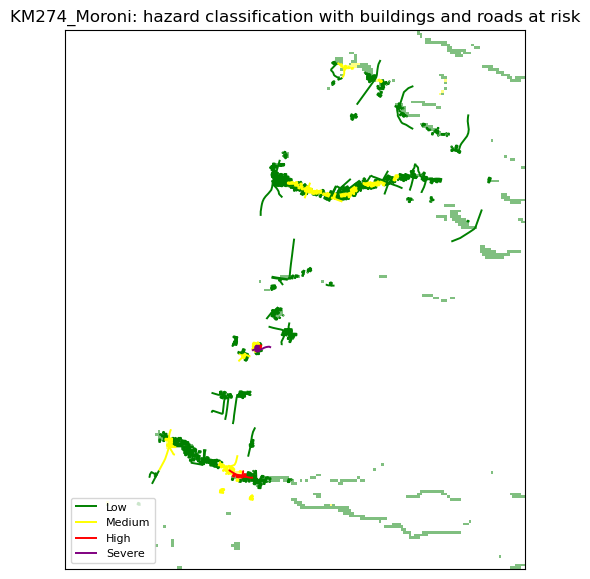

In [7]:
from rasterio.transform import array_bounds

GRID = "70cm"          # whichever raster's grid the overlay is drawn on

geo = to_this_commune(read_receptors(source, read_geometry=True))

rows, cols = meta[GRID]["shape"]
left, bottom, right, top = array_bounds(rows, cols, meta[GRID]["transform"])

geo_grid = geo.to_crs(meta[GRID]["crs"])
geo_grid["hazard"] = classify_features(
    geo_grid.assign(**{f: geo_grid[f].fillna(0.0) for f in PROB_FIELDS}), GATES
)

fig, ax = plt.subplots(figsize=(8, 7))

# Normal and NoData left transparent so the classified areas read clearly.
shaded = np.where((hazard > 0) & (hazard != NODATA), hazard, np.nan).astype("float32")
ax.imshow(shaded, cmap=cmap, norm=norm, interpolation="nearest",
          extent=(left, right, bottom, top), alpha=0.5)

for value, colour in LEVELS:
    subset = geo_grid[geo_grid.hazard == value]
    if not subset.empty:
        subset.plot(ax=ax, color=colour, linewidth=1.4, edgecolor=colour,
                    label=LEVEL_LABEL[value])

ax.set_xlim(left, right)
ax.set_ylim(bottom, top)
ax.set_title(f"{UNIT}: hazard classification with buildings and roads at risk")
ax.set_xticks([]); ax.set_yticks([])
ax.legend(loc="lower left", fontsize=8)
plt.show()

## 6. Building the Comoros plugins

Everything above runs here, in a notebook. To put it on a dashboard the same code
has to become a **plugin**: an installable Python package that TethysDash finds on
its own. The computation does not change — what follows is the wrapper, and the
contracts that wrapper has to satisfy.

### Discovery — three entry points

A plugin is a class registered as an **Intake entry point** in `pyproject.toml`.
The country is part of the name, because each country is a separate row in the
dashboard's dropdown:

```toml
[project.entry-points."intake.drivers"]
uffis_hazard_layer_comoros   = "tgf_wmo_plugins.hazard_layer:HazardLayerComoros"
uffis_impact_layer_comoros   = "tgf_wmo_plugins.impact_layer:ImpactLayerComoros"
uffis_impact_summary_comoros = "tgf_wmo_plugins.impact_summary:ImpactSummaryComoros"
```

The key must match the class's own `name`, or the GUI lists a plugin it cannot
then load.

### The three classes

`BaseHazardLayer` fills `args`, `group`, `tags`, `description` and `label` in
`__init_subclass__` from `LANG` and `country`, so the subclass really is four
lines. Comorian products are francophone, and French already exists in `STRINGS`
because Haiti uses it:

```python
# hazard_layer.py
class HazardLayerComoros(BaseHazardLayer):
    LANG = "fr"
    country = "comoros"
    name = "uffis_hazard_layer_comoros"
```

`BaseImpactLayer` and `BaseImpactSummary` spell the same fields out explicitly:

```python
# impact_layer.py
class ImpactLayerComoros(BaseImpactLayer):
    LANG = "fr"
    country = "comoros"
    args = threshold_args(LANG)
    name = "uffis_impact_layer_comoros"
    label = f"{STRINGS[LANG]['impact_layer_label']} (Comores)"
    group = STRINGS[LANG]["group"]
    tags = ["inondation", "impact", "IBF", "map_layer", "dynamique", "français"]
    description = STRINGS[LANG]["impact_layer_desc"]
```

`ImpactSummaryComoros` is the same shape against `BaseImpactSummary`, with
`hazard_summary_label` and `type = "table"` inherited.

### What the shared tables need

The base classes are driven by a handful of module-level dictionaries, and every
one of them is something section 3 already worked out:

| table | module | Comoros entry |
|---|---|---|
| `PROB_URLS` | `classification` | the four `prob_depth_ge_*_overbank` rasters |
| `PROB_FIELDS` | `common` | `probability_low/med/high/severe`, as renamed |
| `GPKG_LAYERS` | `common` | `{"building": ("buildings", RENAMES), "road": ("roads", RENAMES)}` |
| `TYPE_FIELD` | `common` | `"type"` |
| `TOTAL_POPULATION` | `common` | whichever scope the plugin reports on |
| `FEATURES_URLS`, `MEASURES`, `FEATURE_COLUMNS` | `impact_layer` | the geopackage URL, and the measure columns |
| `COUNTRY_NAMES` | `hazard_layer` | `"Comores"` |

`MEASURES` is the one to read twice. It names the columns the popup shows, and
Comoros spells them exactly as Antigua and Barbuda does —
`population_per_building`, `building_area_m2`, `road_length_m` — so that entry is
a copy. `GPKG_LAYERS` then needs no measure renames at all, only the four
probability columns.

### The first correction: percent

Section 3 divided the probability columns by 100. No existing country needs that,
so there is nowhere in the package it currently belongs. The smallest honest place
is a scale table beside the others, defaulting to 1:

```python
# common.py
# Countries whose geopackage stores exceedance as percent rather than as a
# fraction. Everything downstream -- gates, defaults, the notebooks -- is in
# fractions, so the reader normalises on the way in rather than letting a
# per-country unit leak into the classification.
PROB_SCALE = {"comoros": 0.01}
```

applied once in `_read_geopackage`, after the renames:

```python
scale = PROB_SCALE.get(country, 1.0)
if scale != 1.0:
    part[PROB_FIELDS[country]] *= scale
```

Putting it in the reader rather than in the classifier matters: `gates()` and
`DEFAULT_GATES` are shared by every country, and a unit that reaches them has to
be special-cased in three plugins instead of one function.

### The second correction: which commune

This is the real design decision, and the existing plugins have nothing like it.
Comoros writes one product set per ADM3 commune, so `PROB_URLS["comoros"]` cannot
be a fixed list of four URLs the way Guatemala's and Antigua's are — there are 55
of them. Three options, in increasing order of work:

1. **One plugin per commune.** Fifty-five entry points and fifty-five rows in the
   dropdown. Rejected on sight, but worth stating so the others have a baseline.
2. **Pin one commune per plugin**, as this notebook pins Moroni. Honest, trivially
   implementable, and wrong for an operational product: the capital is not the
   only place that floods.
3. **Make the commune an argument.** The plugin gains a fifth arg alongside the
   four gates, and `PROB_URLS` becomes a function of it:

```python
# classification.py
def comoros_prob_urls(unit):
    base = f"{BUCKET}/Comoros_training/.../fim/{unit}/stream_sat_stormlab/pluvial_overbank"
    return [f"{base}/prob_depth_ge_{d}_overbank.{CYCLE}.tif"
            for d in ("10cm", "30cm", "70cm", "100cm")]


# impact_layer.py / hazard_layer.py
class HazardLayerComoros(BaseHazardLayer):
    LANG = "fr"
    country = "comoros"
    name = "uffis_hazard_layer_comoros"
    # threshold_args gives the four gates; the commune is a dropdown, so it is a
    # list of {"value", "label"} rather than "number".
    args = {**threshold_args("fr"),
            "commune": [{"value": p, "label": n} for p, n in COMOROS_UNITS]}
```

Option 3 is the one to build, and it has a consequence worth being explicit about:
**argument names are a published interface.** A dashboard stores the keys, so
renaming `commune` later silently breaks every dashboard already bound to it —
an undeclared argument does not raise, it just falls back to its default and the
control appears to do nothing. Choose the name before publishing.

The commune argument also subsumes the second half of `to_this_commune`: the
impact summary and impact layer filter the island geopackage on
`ADM3_PCODE == commune`, which is the same line this notebook runs.

### One change that is not just wiring

`BaseHazardLayer.fetch_features` returns its polygons in the raster's own CRS:

```python
return {"type": "FeatureCollection", "features": features,
        "crs": {"type": "name", "properties": {"name": str(crs)}}}
```

That works for Guatemala (EPSG:3857) and Antigua and Barbuda (EPSG:4326) because
those are the two projections OpenLayers resolves without proj4. The Comoros
rasters are **EPSG:5629**, Moznet / UTM zone 38S, which it does not — so the
layer would load and then land nowhere near the Indian Ocean. The hazard layer has
to reproject its vectorised polygons to EPSG:4326 before returning them.

`BaseImpactLayer` already does the equivalent: `_load()` ends with
`gdf.to_crs(OUTPUT_CRS)`, where `OUTPUT_CRS = "EPSG:4326"`. So the impact layer
needs nothing, and the hazard layer needs one `to_crs` it has never needed before.

This is also why a plugin is the answer rather than a plain map layer. TethysDash
can point a vector layer straight at a GeoPackage, but its loader pre-registers
only the WGS84 UTM zones with proj4, and 5629 is not one of them — the same
geometry under a different authority code. A plugin returning GeoJSON in a
projection the frontend resolves sidesteps the whole question.

### Why the two-method split earns its keep

A `map_layer` plugin answers two questions at two different times:

- `run()` fires **once**, when someone is configuring the dashboard. It returns the
  layer's *scaffold* — name, source binding, style rules, legend — which is what
  the layer editor's **Fetch plugin defaults** button calls. It is stored with the
  dashboard.
- `fetch_features()` fires **on load, and on every change to a bound threshold**.
  It returns only the GeoJSON.

Moving a gate therefore re-runs the classification and nothing else. The style is
worth shipping from `run()` for a second reason: the rule shape is fussy — the
condition lives on the rule itself, the operator is `"="` not `"=="`, and the key
is `geometryType`, not `geometry` — and a malformed rule never matches and fails
silently, leaving every feature grey. Hand-authoring eight of those in the GUI is
how you lose an afternoon.

`ImpactSummaryComoros` never touches the rasters at all: the buildings and roads
already carry the four probabilities, so it applies the same gates to the
geopackage exactly as section 3 did.

### Things to try

- Set `UNIT` to another commune — `KM271_BambaoYaHari`, `KM283_OichiliYamboini`,
  `KM331_Mledjele` — and re-run. Only Moroni's population constant has to change
  with it. Note that 33 of the 55 stores were still uploading when this was
  written, so a commune may not resolve.
- Delete the `/ 100.0` in `to_this_commune` and re-run sections 3 and 4. The table
  still looks entirely plausible. That is the point: a units error does not raise,
  it just reports the wrong number confidently.
- Drop the commune filter and keep the Moroni rasters. The table then describes
  Grande Comore and the map describes Moroni. Which of the two would a reader
  assume?
- Compare the `level` column with the `risk_label` the run already wrote into the
  geopackage. They disagree, and should: `risk_label` comes from the Flood Risk
  Matrix, likelihood crossed with severity, while these gates are flat cutoffs on
  probability alone. Which is easier to explain to someone who has to act on it?
- The Comoros chain is pluvial only. What would you have to add to the
  classification if an island model were later run with river inflow?